# TP Deep Learning

## Comparaison entre un CNN entraîné « From Scratch » et le Transfert d’Apprentissage pour la classification Chats vs Chiens

**Étudiant :** Don Bosenga

**Cours :** Deep Learning

**Institution :** Dakar Institute of Technology (DIT)

**Date :** 29 Mai 2026

# 1. Introduction

L’objectif de ce travail est de comparer deux approches différentes pour résoudre un problème de classification binaire d’images (Chats vs Chiens) :

1. Un réseau de neurones convolutif (CNN) entraîné à partir de zéro (From Scratch).
2. Une approche basée sur le transfert d’apprentissage (Transfer Learning) à l’aide d’un modèle pré-entraîné.

Les performances des deux approches seront évaluées à l’aide de plusieurs métriques telles que l’accuracy, la précision, le rappel et la fonction de perte (loss).

# 2. Importation des bibliothèques nécessaires

In [ ]:
import torch
import os
import random
import numpy as np


print(torch.__version__)
print(torch.backends.mps.is_available())

2.12.0
True


# 3. Reproductibilité et configuration matérielle

Afin de garantir la reproductibilité des résultats, une graine aléatoire (seed) est fixée. Le calcul sera effectué sur GPU lorsqu’il est disponible.

In [5]:
SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.backends.mps.is_available():
    device = torch.device("mps")
elif torch.cuda.is_available():
    device = torch.device("cuda")
else:
    device = torch.device("cpu")

print("Device utilisé :", device)

Device utilisé : mps


# 4. Chargement et prétraitement des données

Cette étape consiste à charger le jeu de données Cats vs Dogs, appliquer les transformations nécessaires et préparer les ensembles d'entraînement, de validation et de test.

In [6]:
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, random_split

data_dir = "data/cat_dog_data"

train_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])

test_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])

full_train_data = datasets.ImageFolder(data_dir + "/train", transform=train_transforms)
test_data = datasets.ImageFolder(data_dir + "/test", transform=test_transforms)

val_size = int(0.2 * len(full_train_data))
train_size = len(full_train_data) - val_size

train_data, val_data = random_split(
    full_train_data,
    [train_size, val_size],
    generator=torch.Generator().manual_seed(SEED)
)

trainloader = DataLoader(train_data, batch_size=32, shuffle=True)
valloader = DataLoader(val_data, batch_size=32, shuffle=False)
testloader = DataLoader(test_data, batch_size=32, shuffle=False)

print(full_train_data.class_to_idx)
print("Train:", len(train_data))
print("Validation:", len(val_data))
print("Test:", len(test_data))

{'cat': 0, 'dog': 1}
Train: 18000
Validation: 4500
Test: 2500


# 5. Visualisation du jeu de données

Avant l’entraînement du modèle, il est important d’explorer visuellement quelques exemples d’images afin de vérifier la qualité des données.

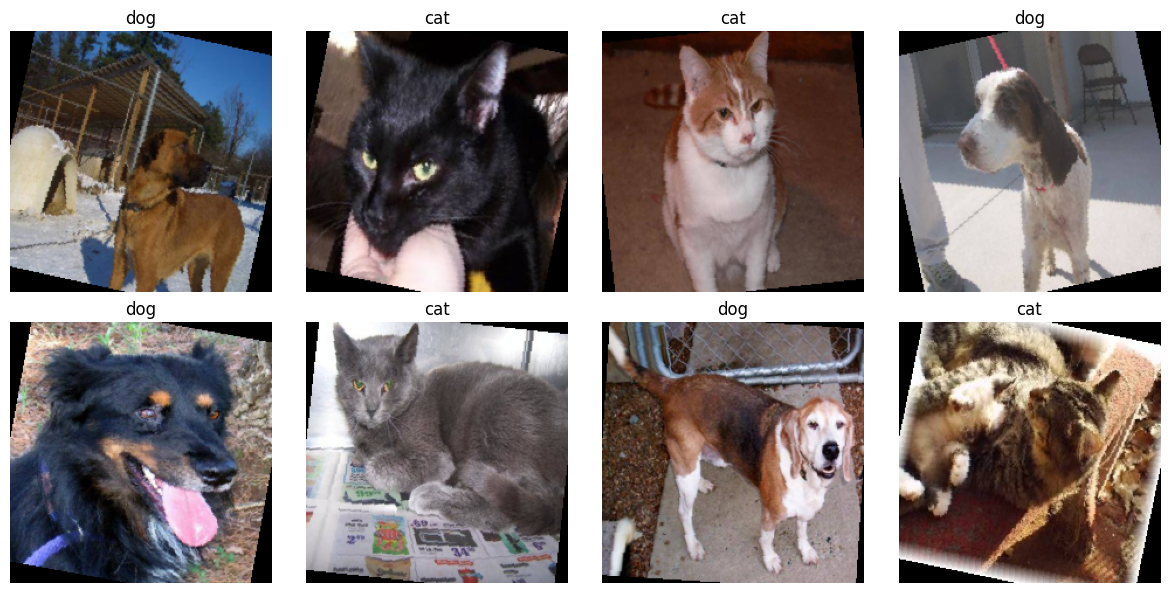

In [8]:
import matplotlib.pyplot as plt
import numpy as np

# Classes
classes = train_data.dataset.classes

# Récupération d'un batch
images, labels = next(iter(trainloader))

# Affichage de 8 images
fig, axes = plt.subplots(2, 4, figsize=(12,6))

for i, ax in enumerate(axes.flat):

    img = images[i]

    # dénormalisation
    img = img.numpy().transpose((1,2,0))

    mean = np.array([0.485, 0.456, 0.406])
    std = np.array([0.229, 0.224, 0.225])

    img = std * img + mean
    img = np.clip(img, 0, 1)

    ax.imshow(img)
    ax.set_title(classes[labels[i]])
    ax.axis('off')

plt.tight_layout()
plt.show()

# 6. Expérience A : CNN entraîné From Scratch

Dans cette première expérience, nous construisons un réseau de neurones convolutif (CNN) à partir de zéro afin de classifier les images de chats et de chiens.

Le modèle est composé de trois blocs convolutionnels comprenant :
- une couche de convolution ;
- une couche Batch Normalization ;
- une fonction d'activation ReLU ;
- une couche de Max Pooling.

Des couches Dropout sont également utilisées pour réduire le risque de surapprentissage.

## 6.1 Architecture du modèle

L'architecture retenue est la suivante :

Entrée (224×224×3)

→ Conv2D (32 filtres)
→ BatchNorm
→ ReLU
→ MaxPool

→ Conv2D (64 filtres)
→ BatchNorm
→ ReLU
→ MaxPool

→ Conv2D (128 filtres)
→ BatchNorm
→ ReLU
→ MaxPool

→ Flatten

→ Dense (256 neurones)

→ Dropout (0.5)

→ Dense (2 neurones)

In [9]:
import torch.nn as nn

class CNNFromScratch(nn.Module):

    def __init__(self):

        super(CNNFromScratch, self).__init__()

        self.features = nn.Sequential(

            # Bloc 1
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2),

            # Bloc 2
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2),

            # Bloc 3
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )

        self.classifier = nn.Sequential(

            nn.Flatten(),

            nn.Linear(128 * 28 * 28, 256),

            nn.ReLU(),

            nn.Dropout(0.5),

            nn.Linear(256, 2)
        )

    def forward(self, x):

        x = self.features(x)

        x = self.classifier(x)

        return x

In [10]:
model_scratch = CNNFromScratch().to(device)

print(model_scratch)

CNNFromScratch(
  (features): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (2): ReLU()
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (4): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (5): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (6): ReLU()
    (7): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (8): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (9): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (10): ReLU()
    (11): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=100352, out_features=256, bi

## 6.2 Fonction de coût et optimiseur

La fonction de coût utilisée est CrossEntropyLoss, adaptée aux problèmes de classification.

Deux optimiseurs seront comparés :

- Adam
- SGD

In [11]:
import torch.optim as optim

criterion = nn.CrossEntropyLoss()

optimizer_adam = optim.Adam(
    model_scratch.parameters(),
    lr=0.001
)

optimizer_sgd = optim.SGD(
    model_scratch.parameters(),
    lr=0.01,
    momentum=0.9
)

print("Criterion :", criterion)
print("Adam :", optimizer_adam)
print("SGD :", optimizer_sgd)

Criterion : CrossEntropyLoss()
Adam : Adam (
Parameter Group 0
    amsgrad: False
    betas: (0.9, 0.999)
    capturable: False
    decoupled_weight_decay: False
    differentiable: False
    eps: 1e-08
    foreach: None
    fused: None
    lr: 0.001
    maximize: False
    weight_decay: 0
)
SGD : SGD (
Parameter Group 0
    dampening: 0
    differentiable: False
    foreach: None
    fused: None
    lr: 0.01
    maximize: False
    momentum: 0.9
    nesterov: False
    weight_decay: 0
)


## 6.3 Entraînement du modèle

Le modèle est entraîné sur l’ensemble d’apprentissage pendant plusieurs époques. Les métriques suivantes sont enregistrées :

- Loss
- Accuracy
- Precision
- Recall

In [13]:
from sklearn.metrics import accuracy_score
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score

def evaluate_model(model, dataloader):

    model.eval()

    all_preds = []
    all_labels = []

    with torch.no_grad():

        for images, labels in dataloader:

            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)

            preds = torch.argmax(outputs, dim=1)

            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    acc = accuracy_score(all_labels, all_preds)

    prec = precision_score(
        all_labels,
        all_preds,
        average='binary'
    )

    rec = recall_score(
        all_labels,
        all_preds,
        average='binary'
    )

    return acc, prec, rec

## 6.4 Courbes d’apprentissage

Les courbes de perte et de performance permettent d’analyser la convergence du modèle et de détecter un éventuel surapprentissage.

In [14]:
def train_model(
        model,
        trainloader,
        valloader,
        criterion,
        optimizer,
        epochs=10):

    train_losses = []

    val_accuracies = []
    val_precisions = []
    val_recalls = []

    best_acc = 0

    for epoch in range(epochs):

        model.train()

        running_loss = 0

        for images, labels in trainloader:

            images = images.to(device)
            labels = labels.to(device)

            optimizer.zero_grad()

            outputs = model(images)

            loss = criterion(outputs, labels)

            loss.backward()

            optimizer.step()

            running_loss += loss.item()

        epoch_loss = running_loss / len(trainloader)

        train_losses.append(epoch_loss)

        acc, prec, rec = evaluate_model(
            model,
            valloader
        )

        val_accuracies.append(acc)
        val_precisions.append(prec)
        val_recalls.append(rec)

        print(
            f"Epoch [{epoch+1}/{epochs}] "
            f"Loss={epoch_loss:.4f} "
            f"Acc={acc:.4f} "
            f"Prec={prec:.4f} "
            f"Recall={rec:.4f}"
        )

        if acc > best_acc:

            best_acc = acc

            torch.save(
                model.state_dict(),
                "best_cnn_scratch.pth"
            )

    return (
        train_losses,
        val_accuracies,
        val_precisions,
        val_recalls
    )

In [15]:
EPOCHS = 3

results_adam = train_model(
    model_scratch,
    trainloader,
    valloader,
    criterion,
    optimizer_adam,
    epochs=EPOCHS
)

Epoch [1/3] Loss=1.5899 Acc=0.6127 Prec=0.7359 Recall=0.3536
Epoch [2/3] Loss=0.6389 Acc=0.6631 Prec=0.6718 Recall=0.6402
Epoch [3/3] Loss=0.6346 Acc=0.6847 Prec=0.7727 Recall=0.5248


### Analyse préliminaire

Après trois époques d'entraînement avec l'optimiseur Adam, le CNN entraîné from scratch montre une amélioration progressive de ses performances. La fonction de perte diminue nettement entre la première et la deuxième époque, ce qui indique que le modèle apprend à extraire des caractéristiques utiles des images.

L'accuracy de validation passe d'environ 61 % à 68 %, ce qui montre une convergence initiale encourageante. Toutefois, les résultats restent encore modestes, ce qui est normal pour un modèle entraîné from scratch sur un nombre limité d'époques. Un entraînement plus long, une meilleure régularisation et une comparaison avec le transfert d'apprentissage permettront d'évaluer plus clairement les performances.

In [17]:
EPOCHS = 10

results_adam = train_model(
    model_scratch,
    trainloader,
    valloader,
    criterion,
    optimizer_adam,
    epochs=EPOCHS
)

Epoch [1/10] Loss=0.6144 Acc=0.6991 Prec=0.7577 Recall=0.5870
Epoch [2/10] Loss=0.6150 Acc=0.6880 Prec=0.7714 Recall=0.5359
Epoch [3/10] Loss=0.6080 Acc=0.6544 Prec=0.8836 Recall=0.3571
Epoch [4/10] Loss=0.5912 Acc=0.6984 Prec=0.8078 Recall=0.5222
Epoch [5/10] Loss=0.5803 Acc=0.7087 Prec=0.8652 Recall=0.4956
Epoch [6/10] Loss=0.5678 Acc=0.6929 Prec=0.8556 Recall=0.4654
Epoch [7/10] Loss=0.5433 Acc=0.7387 Prec=0.8697 Recall=0.5626
Epoch [8/10] Loss=0.5250 Acc=0.7762 Prec=0.7729 Recall=0.7835
Epoch [9/10] Loss=0.5040 Acc=0.7553 Prec=0.9092 Recall=0.5683
Epoch [10/10] Loss=0.4903 Acc=0.7860 Prec=0.8826 Recall=0.6606


## Analyse des résultats du CNN entraîné From Scratch

Après 10 époques d'entraînement avec l'optimiseur Adam, le modèle atteint une accuracy de validation de 78,60 %.

La fonction de perte diminue progressivement de 0,61 à 0,49, ce qui indique une amélioration continue de l'apprentissage.

La précision atteint 88,26 %, ce qui signifie que lorsque le modèle prédit une image comme étant un chien, cette prédiction est généralement correcte.

Le rappel atteint 66,06 %, ce qui indique qu'une partie des chiens présents dans le jeu de données n'est pas encore correctement identifiée.

Ces résultats montrent qu'un CNN entraîné à partir de zéro est capable d'apprendre efficacement les caractéristiques des images, mais ses performances restent limitées par rapport aux approches de transfert d'apprentissage qui bénéficient de connaissances préalablement acquises sur de grands jeux de données.

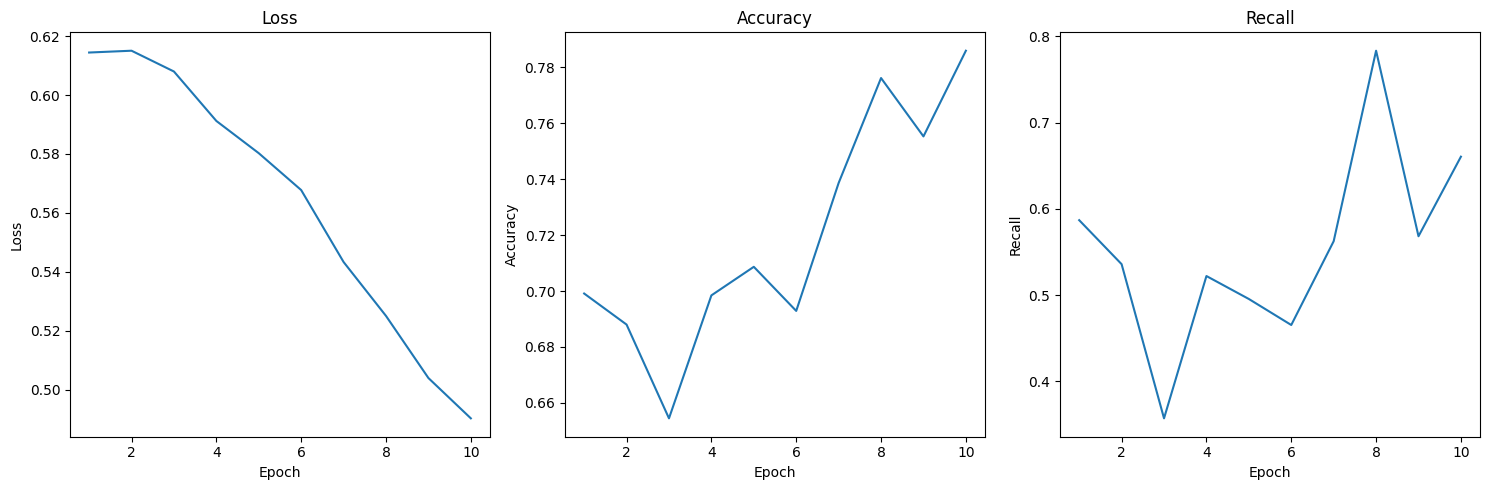

In [18]:
train_losses = results_adam[0]
val_accuracies = results_adam[1]
val_precisions = results_adam[2]
val_recalls = results_adam[3]

epochs_range = range(1, len(train_losses)+1)

plt.figure(figsize=(15,5))

plt.subplot(1,3,1)
plt.plot(epochs_range, train_losses)
plt.title("Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.subplot(1,3,2)
plt.plot(epochs_range, val_accuracies)
plt.title("Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")

plt.subplot(1,3,3)
plt.plot(epochs_range, val_recalls)
plt.title("Recall")
plt.xlabel("Epoch")
plt.ylabel("Recall")

plt.tight_layout()
plt.show()

In [19]:
model_sgd = CNNFromScratch().to(device)

optimizer_sgd = optim.SGD(
    model_sgd.parameters(),
    lr=0.01,
    momentum=0.9
)

results_sgd = train_model(
    model_sgd,
    trainloader,
    valloader,
    criterion,
    optimizer_sgd,
    epochs=10
)

Epoch [1/10] Loss=0.7243 Acc=0.5009 Prec=0.5009 Recall=1.0000
Epoch [2/10] Loss=0.6935 Acc=0.5009 Prec=0.5009 Recall=1.0000


/Users/donbosenga/Desktop/cnn-catsdogs-DonBosenga/.venv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


Epoch [3/10] Loss=0.6938 Acc=0.4991 Prec=0.0000 Recall=0.0000


/Users/donbosenga/Desktop/cnn-catsdogs-DonBosenga/.venv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


Epoch [4/10] Loss=0.6934 Acc=0.4991 Prec=0.0000 Recall=0.0000


/Users/donbosenga/Desktop/cnn-catsdogs-DonBosenga/.venv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


Epoch [5/10] Loss=0.6934 Acc=0.4991 Prec=0.0000 Recall=0.0000
Epoch [6/10] Loss=0.6935 Acc=0.5009 Prec=0.5009 Recall=1.0000
Epoch [7/10] Loss=0.6936 Acc=0.5009 Prec=0.5009 Recall=1.0000


/Users/donbosenga/Desktop/cnn-catsdogs-DonBosenga/.venv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


Epoch [8/10] Loss=0.6937 Acc=0.4991 Prec=0.0000 Recall=0.0000
Epoch [9/10] Loss=0.6936 Acc=0.5009 Prec=0.5009 Recall=1.0000
Epoch [10/10] Loss=0.6937 Acc=0.5009 Prec=0.5009 Recall=1.0000


Avec un learning rate de 0.01, l'optimiseur SGD n'a pas permis au modèle de converger correctement. La loss est restée proche de 0.693 et l'accuracy autour de 50 %, ce qui correspond à une performance proche du hasard pour une classification binaire. Ce comportement indique que le learning rate initial était probablement mal adapté. Un second essai avec un learning rate plus faible a donc été réalisé.

In [20]:
model_sgd = CNNFromScratch().to(device)

optimizer_sgd = optim.SGD(
    model_sgd.parameters(),
    lr=0.001,
    momentum=0.9
)

results_sgd = train_model(
    model_sgd,
    trainloader,
    valloader,
    criterion,
    optimizer_sgd,
    epochs=10
)

Epoch [1/10] Loss=0.6402 Acc=0.6778 Prec=0.7485 Recall=0.5373
Epoch [2/10] Loss=0.5972 Acc=0.7038 Prec=0.7523 Recall=0.6091
Epoch [3/10] Loss=0.5718 Acc=0.7247 Prec=0.7793 Recall=0.6282
Epoch [4/10] Loss=0.5548 Acc=0.7327 Prec=0.7466 Recall=0.7059
Epoch [5/10] Loss=0.5325 Acc=0.7413 Prec=0.8785 Recall=0.5612
Epoch [6/10] Loss=0.5141 Acc=0.7411 Prec=0.8566 Recall=0.5803
Epoch [7/10] Loss=0.5041 Acc=0.7607 Prec=0.7713 Recall=0.7422
Epoch [8/10] Loss=0.4863 Acc=0.7673 Prec=0.7757 Recall=0.7533
Epoch [9/10] Loss=0.4784 Acc=0.7780 Prec=0.8515 Recall=0.6744
Epoch [10/10] Loss=0.4632 Acc=0.7880 Prec=0.8174 Recall=0.7427


## 6.5 Comparaison visuelle des optimiseurs Adam et SGD


Cette section compare les performances obtenues avec les optimiseurs Adam et SGD à l'aide des courbes d'apprentissage.

Les métriques étudiées sont :

- Loss

- Accuracy

- Precision

- Recall

### Comparaison Adam vs SGD

Les deux optimiseurs obtiennent des performances proches après 10 époques. Adam atteint une accuracy de 78,60 %, tandis que SGD avec un learning rate de 0.001 atteint 78,80 %.

Adam présente une précision plus élevée, ce qui signifie qu’il produit moins de faux positifs lorsqu’il prédit la classe chien. En revanche, SGD obtient un meilleur rappel, indiquant qu’il identifie davantage d’images de chiens correctement.

Le premier essai avec SGD et un learning rate de 0.01 n’a pas convergé correctement, avec une accuracy proche de 50 %. Cela montre l’importance du choix du learning rate dans l’optimisation d’un réseau de neurones.

In [21]:
adam_loss = results_adam[0]
adam_acc = results_adam[1]
adam_prec = results_adam[2]
adam_rec = results_adam[3]

sgd_loss = results_sgd[0]
sgd_acc = results_sgd[1]
sgd_prec = results_sgd[2]
sgd_rec = results_sgd[3]

epochs = range(1, len(adam_loss)+1)

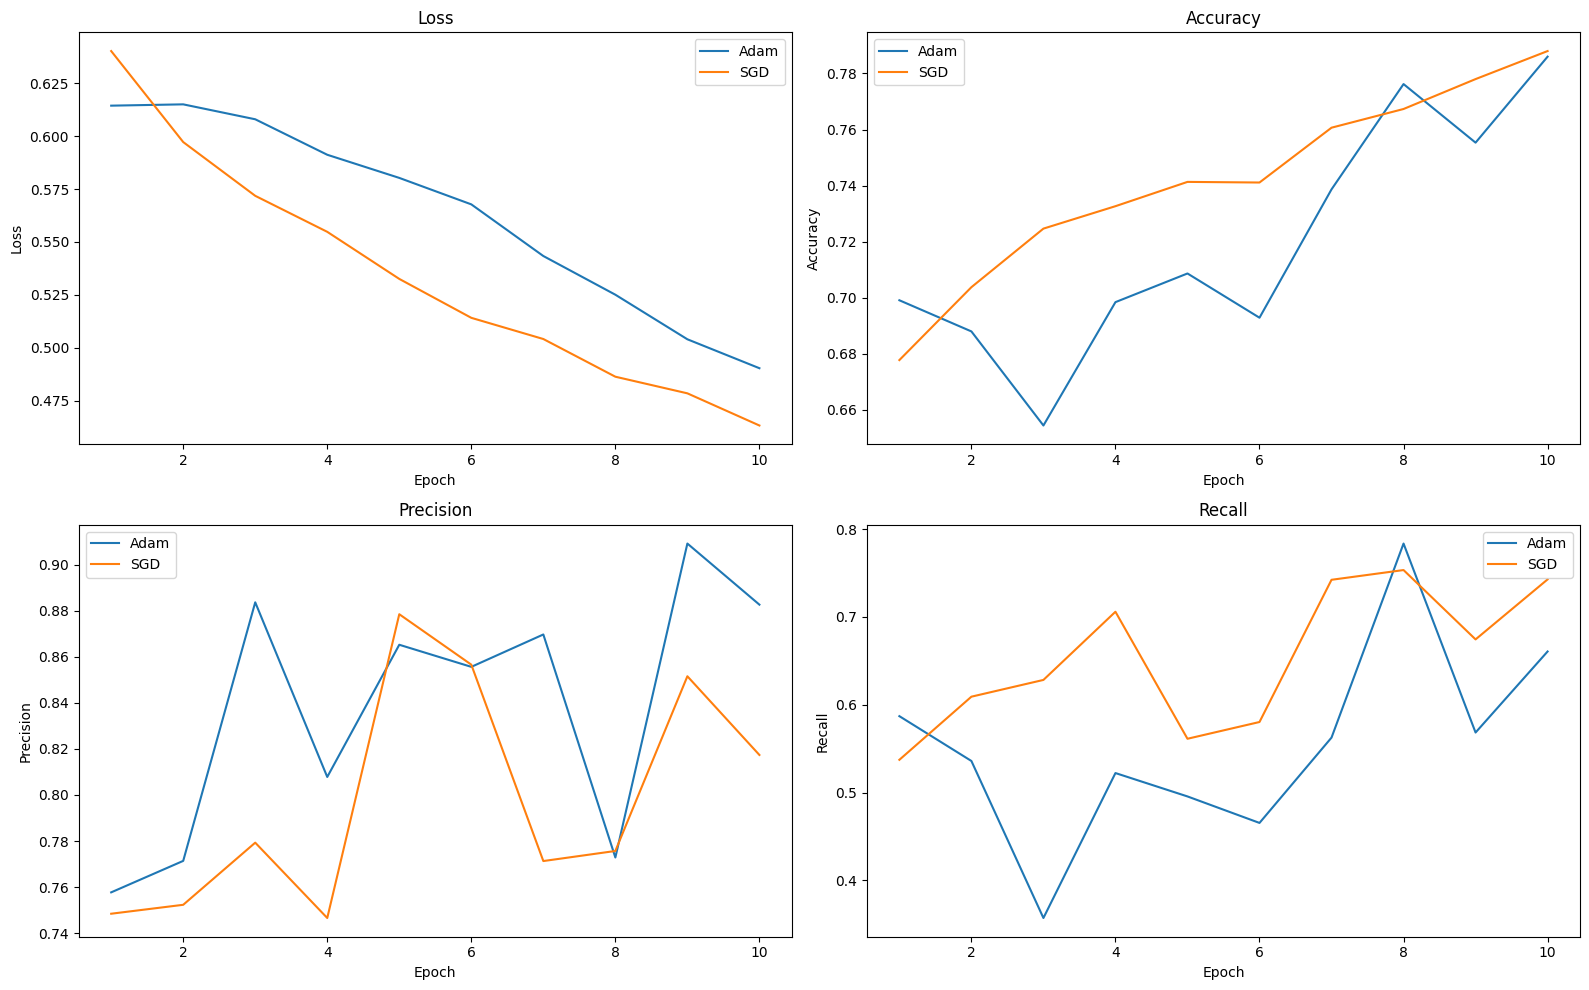

In [22]:
plt.figure(figsize=(16,10))

# Loss
plt.subplot(2,2,1)
plt.plot(epochs, adam_loss, label='Adam')
plt.plot(epochs, sgd_loss, label='SGD')
plt.title('Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

# Accuracy
plt.subplot(2,2,2)
plt.plot(epochs, adam_acc, label='Adam')
plt.plot(epochs, sgd_acc, label='SGD')
plt.title('Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

# Precision
plt.subplot(2,2,3)
plt.plot(epochs, adam_prec, label='Adam')
plt.plot(epochs, sgd_prec, label='SGD')
plt.title('Precision')
plt.xlabel('Epoch')
plt.ylabel('Precision')
plt.legend()

# Recall
plt.subplot(2,2,4)
plt.plot(epochs, adam_rec, label='Adam')
plt.plot(epochs, sgd_rec, label='SGD')
plt.title('Recall')
plt.xlabel('Epoch')
plt.ylabel('Recall')
plt.legend()

plt.tight_layout()
plt.show()

In [23]:
import pandas as pd

comparison_df = pd.DataFrame({
    "Optimiseur": ["Adam", "SGD"],
    "Accuracy": [adam_acc[-1], sgd_acc[-1]],
    "Precision": [adam_prec[-1], sgd_prec[-1]],
    "Recall": [adam_rec[-1], sgd_rec[-1]]
})

comparison_df

,Optimiseur,Accuracy,Precision,Recall
0,Adam,0.786,0.882632,0.660603
1,SGD,0.788,0.817383,0.742680


## 6.6 Évaluation finale du CNN From Scratch

Après l'entraînement, le meilleur modèle sauvegardé est rechargé afin d'être évalué sur le jeu de test.  
Cette étape permet de mesurer la capacité réelle du modèle à généraliser sur des images qu'il n'a jamais vues.

In [24]:
# Rechargement du meilleur modèle CNN From Scratch
best_cnn_scratch = CNNFromScratch().to(device)

best_cnn_scratch.load_state_dict(
    torch.load("best_cnn_scratch.pth", map_location=device)
)

best_cnn_scratch.eval()

test_acc, test_prec, test_rec = evaluate_model(
    best_cnn_scratch,
    testloader
)

print("Résultats finaux sur le jeu de test")
print(f"Accuracy : {test_acc:.4f}")
print(f"Precision : {test_prec:.4f}")
print(f"Recall : {test_rec:.4f}")

Résultats finaux sur le jeu de test
Accuracy : 0.7992
Precision : 0.8252
Recall : 0.7592


## 6.7 Matrice de confusion

La matrice de confusion permet d'analyser plus précisément les erreurs du modèle en comparant les classes réelles avec les classes prédites.

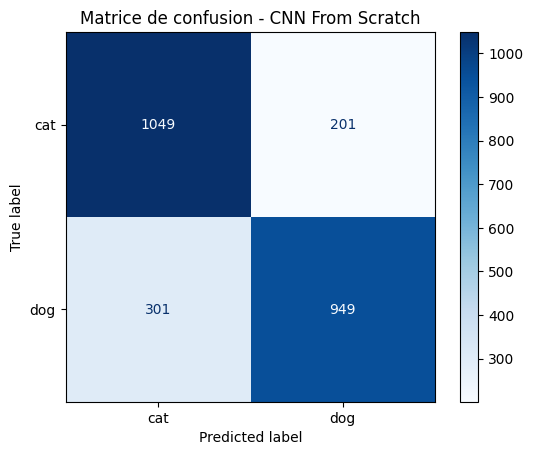

In [25]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

all_preds = []
all_labels = []

best_cnn_scratch.eval()

with torch.no_grad():
    for images, labels in testloader:
        images = images.to(device)
        labels = labels.to(device)

        outputs = best_cnn_scratch(images)
        preds = torch.argmax(outputs, dim=1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

cm = confusion_matrix(all_labels, all_preds)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=test_data.classes
)

disp.plot(cmap="Blues")
plt.title("Matrice de confusion - CNN From Scratch")
plt.show()

### Analyse de la matrice de confusion

La matrice de confusion montre que le modèle classe correctement 1049 images de chats et 949 images de chiens.

Les principales erreurs proviennent de 201 chats classés comme chiens et de 301 chiens classés comme chats.

Ces résultats indiquent que le modèle est globalement performant mais rencontre encore des difficultés lorsque certaines images présentent des caractéristiques visuelles similaires entre les deux classes.

L'accuracy globale obtenue est proche de 80 %, ce qui constitue un résultat satisfaisant pour un CNN entraîné entièrement à partir de zéro.

# 7. Expérience B : Transfert d’apprentissage

## 7.1 Choix du modèle pré-entraîné

Dans cette expérience, nous utilisons ResNet18 pré-entraîné sur ImageNet.

L’objectif est de réutiliser les connaissances déjà apprises sur plusieurs millions d’images afin d’améliorer les performances du modèle sur notre problème de classification Chats vs Chiens.

## 7.2 Adaptation du modèle

Les couches de convolution pré-entraînées sont conservées tandis que la dernière couche de classification est remplacée afin de produire deux classes :

- Chat
- Chien

## 7.3 Entraînement du modèle de transfert d’apprentissage

# 8. Évaluation finale

Les modèles sont évalués sur l’ensemble de test à l’aide des métriques suivantes :

- Accuracy
- Precision
- Recall

# 9. Matrice de confusion

La matrice de confusion permet d’identifier les erreurs de classification réalisées par le modèle.

# 10. Analyse comparative

Cette section présente une comparaison détaillée entre :

- Le CNN entraîné From Scratch
- Le modèle utilisant le Transfert d’Apprentissage

Les performances, la vitesse de convergence et la robustesse des modèles sont analysées.

# 11. Conclusion

Ce travail a permis de comparer deux approches de classification d’images.

Les résultats montrent les avantages et les limites de chaque méthode. Le transfert d’apprentissage permet généralement d’obtenir de meilleures performances avec moins de temps d’entraînement, tandis que le CNN entraîné From Scratch offre une meilleure compréhension du fonctionnement interne des réseaux convolutifs.